In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

"""
image input  = (B, 375, 1200, 3)
hidden state = (B, 128, 375, 1200)
output       = (B, 375, 1200, 3)
"""

class ConvolutionLayer(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, kernel_size=3, padding=1):
        super(ConvolutionLayer, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=padding)
        self.conv3 = nn.Conv2d(hidden_channels, in_channels, kernel_size, padding=padding)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (B, H, W, C)
        x = x.permute(0, 3, 1, 2)          # (B, C, H, W)
        
        x = self.relu(self.conv1(x))       # (B, 128, H, W)
        x = self.relu(self.conv2(x))       # (B, 128, H, W)
        x = self.conv3(x)                  # (B, 3, H, W)
        
        x = x.permute(0, 2, 3, 1)          # (B, H, W, C)
        return x


# Example
B, H, W, C = 2, 375, 1200, 3
inp = torch.randn(B, H, W, C)

model = ConvolutionLayer()
out = model(inp)

print("Input shape :", inp.shape)
print("Output shape:", out.shape)


Input shape : torch.Size([2, 375, 1200, 3])
Output shape: torch.Size([2, 375, 1200, 3])


In [1]:
import sys
import os
import json
import numpy as np
sys.path.append("../")
import utils.kitti_loader as kitti_loader
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

def image_resize(img, target_size=(1200, 375)):
    """
    Crop the image to match the target aspect ratio, then resize.
    Handles:
      - torch tensors (CPU) or numpy arrays
      - channels-first (C,H,W) or channels-last (H,W,C)
      - float images in [0,1] or [0,255]
      - grayscale images

    Args:
        img: np.ndarray or torch.Tensor
        target_size: (width, height)

    Returns:
        np.ndarray: uint8 cropped+resized image (H_out, W_out, C)
    """
    # if torch tensor, convert to numpy
    try:
        import torch
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
    except Exception:
        pass

    arr = np.array(img)  # copy but safe

    # Channels-first (C, H, W) -> (H, W, C)
    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4) and arr.shape[0] <= 4 and arr.shape[0] != arr.shape[2]:
        # Heuristic: if first dim is small (1/3/4) and not equal to last dim, treat as C,H,W
        arr = np.transpose(arr, (1, 2, 0))

    # If grayscale (H, W) -> convert to (H, W, 3)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    # Ensure channels-last 3-channel
    if arr.ndim != 3 or arr.shape[2] not in (1, 3, 4):
        raise ValueError(f"Unsupported image shape after preprocessing: {arr.shape}")

    # Convert floats to uint8
    if np.issubdtype(arr.dtype, np.floating):
        # if values appear normalized in [0,1], scale; otherwise clip
        mx = arr.max()
        if mx <= 1.0:
            arr = (arr * 255.0).clip(0, 255)
        else:
            arr = arr.clip(0, 255)
        arr = arr.astype(np.uint8)
    elif arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)

    arr = np.ascontiguousarray(arr)

    pil_img = Image.fromarray(arr)
    out = ImageOps.fit(
        pil_img,
        target_size,                 # (width, height)
        method=Image.LANCZOS,        # high-quality resampling
        centering=(0.5, 0.5)         # center crop
    )
    return np.array(out)  # uint8 HxWxC


In [ ]:
# save the resized image
for i in img:
    resized_img = image_resize(i, target_size=(1200, 375))
    plt.imsave(f"resized_image_{img.index(i)}.png", resized_img)

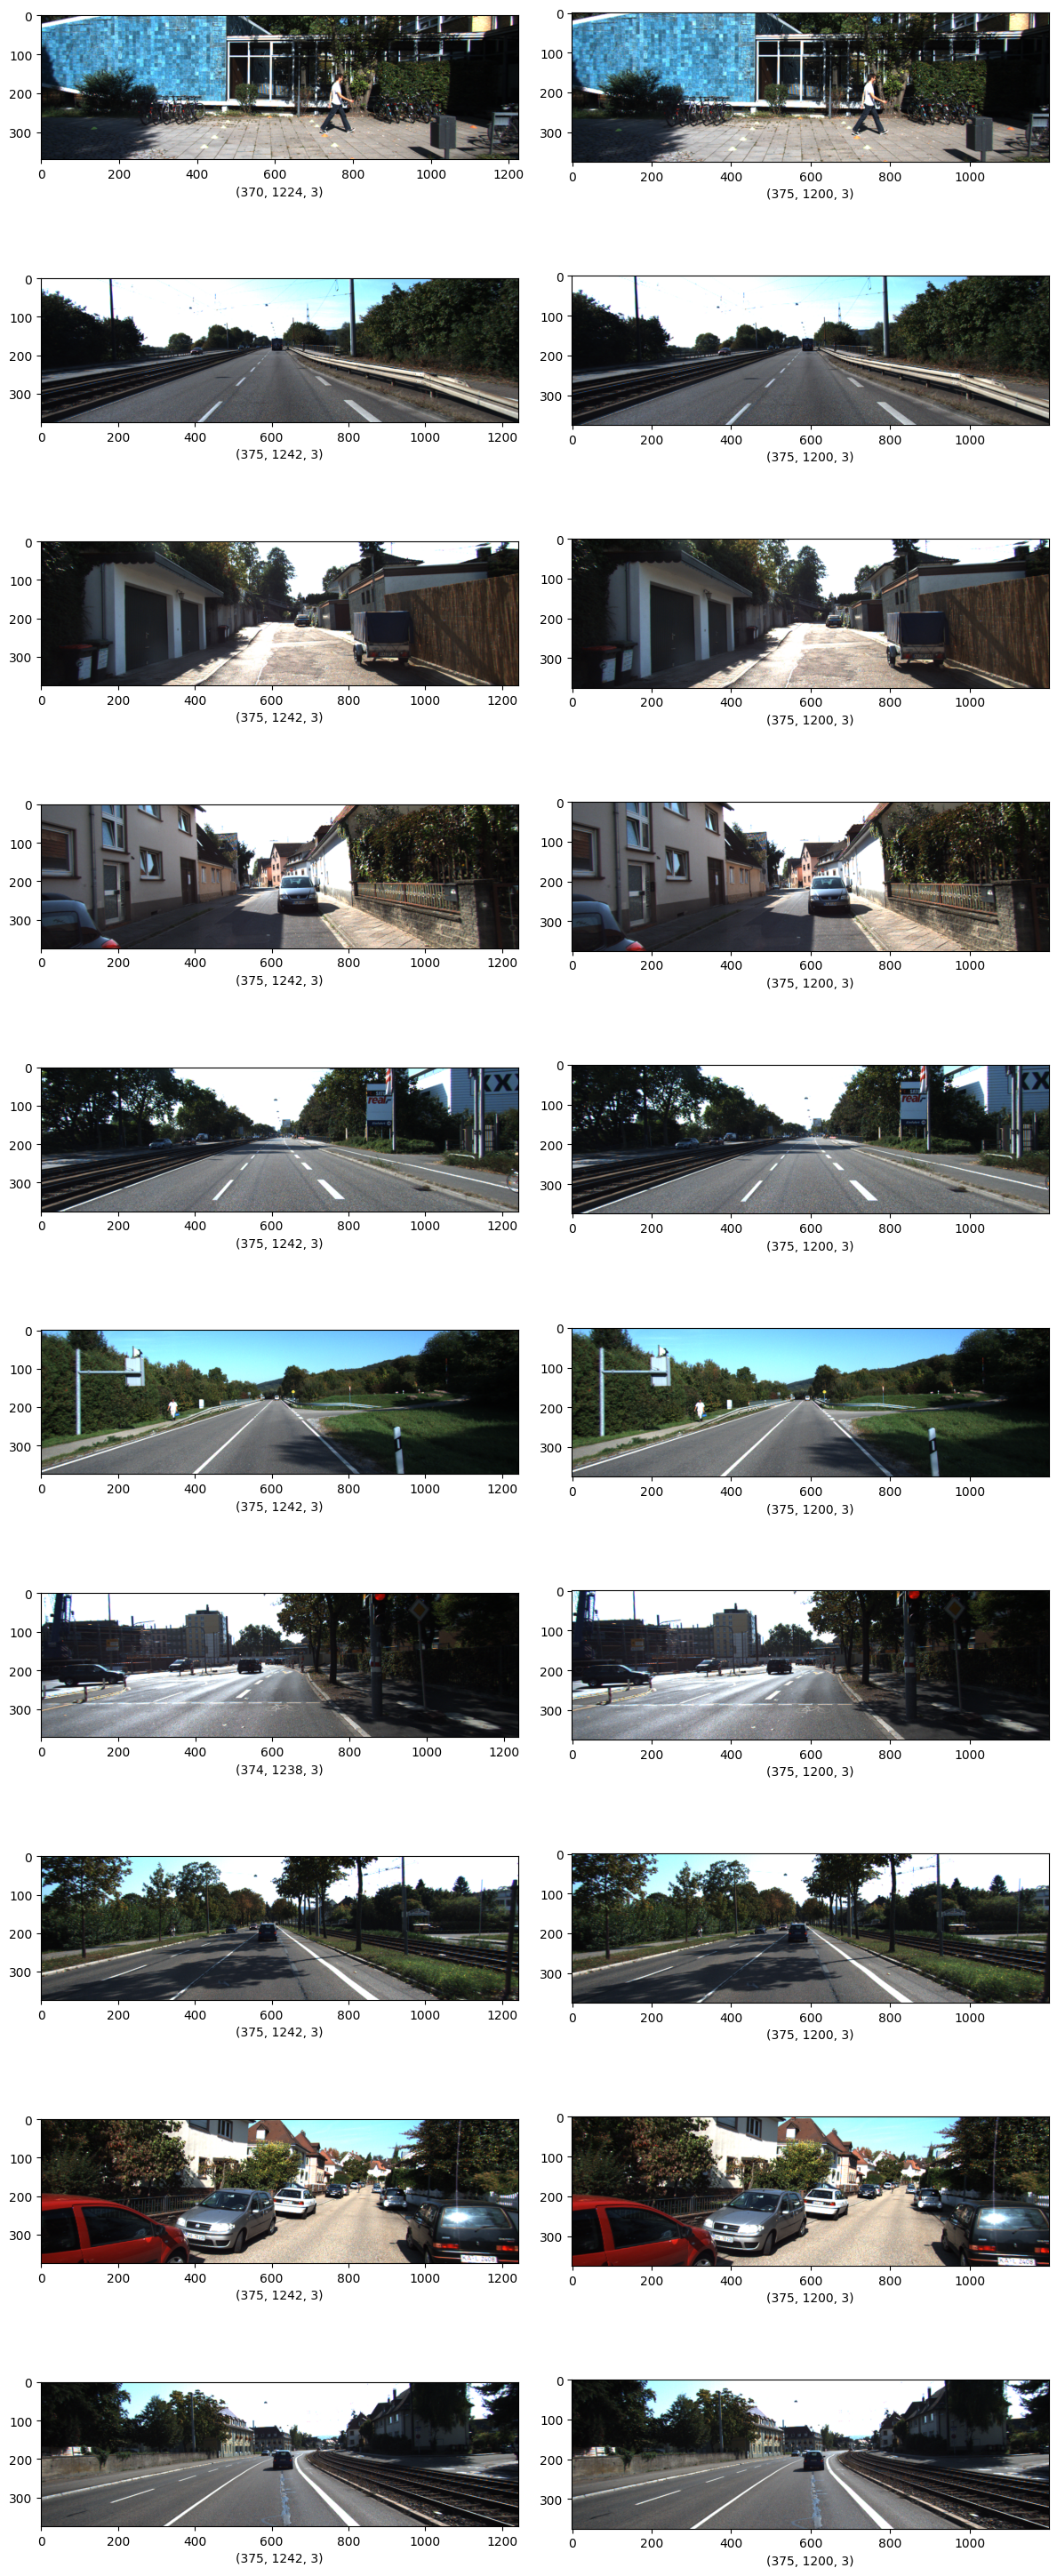

In [16]:
# choose a sensible figure size for the whole grid
fig, axs = plt.subplots(10, 2, figsize=(12, 30))  # width, height in inches

for i in range(10):
    axs[i, 0].imshow(img[i])
    # axs[i, 0].axis('off')
    axs[i, 0].set_xlabel(img[i].shape)
    img_resized = image_resize(img[i])  # use the robust function above
    axs[i, 1].imshow(img_resized)
    # axs[i, 1].axis('off')
    axs[i, 1].set_xlabel(img_resized.shape)
plt.tight_layout()
plt.show()
